In [1]:
# =====================================================================
# DAY 3 — LIME EXPLANATION GENERATION
# MSc Dissertation — Rajarajachozhan V K (03189049)
# Comparative Evaluation of Explainable AI Methods for Customer Churn
# Prediction in Telecommunications: A SHAP- and LIME-Based Framework
# with Marketer-Oriented Segmentation
# ---------------------------------------------------------------------
# PURPOSE: Generate LIME explanations for the best model on the SAME
#          500-customer eval set used for SHAP (Day 2), enabling a
#          like-for-like SHAP-vs-LIME comparison in Day 4.
#
# INPUTS : *_tuned.pkl, test_data.pkl, shap_outputs.pkl, *_shap_eval.csv
# OUTPUTS: lime_eval.csv, lime_outputs.pkl
#
# NOTES  : discretize_continuous=False -> one weight per real feature
#          random_state=42             -> reproducible run
#          (LIME's inherent variance is measured as STABILITY in Day 4)
#          Same model + same customers + same features as SHAP.
# PHASE  : 6 (SHAP & LIME) -> feeds Phase 7 (four-metric evaluation)
# =====================================================================
print("DAY 3 — LIME EXPLANATION GENERATION")
print("MSc Dissertation — Rajarajachozhan V K (03189049)")
print("Best model explained by LIME on the canonical 500-customer eval set.")

DAY 3 — LIME EXPLANATION GENERATION
MSc Dissertation — Rajarajachozhan V K (03189049)
Best model explained by LIME on the canonical 500-customer eval set.


In [2]:
# ============================================================
# SETUP: Mount Drive, paths, install (lime + shap)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = "/content/drive/MyDrive/MSc_Dissertation/data/"
MODEL_PATH = "/content/drive/MyDrive/MSc_Dissertation/models/"

!pip install xgboost imbalanced-learn shap lime -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# ============================================================
# IMPORTS + CONFIG + HELPER
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap, pickle, time, warnings
import lime, lime.lime_tabular
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')
np.random.seed(42)

# ---- Config ----
NUM_SAMPLES = 3000   # LIME perturbations per instance (higher = more stable, slower)
TOPK        = 10     # top-k features for the SHAP-vs-LIME overlap teaser

def lime_to_vector(exp, n_features, label=1):
    """Turn a LIME explanation into a full-length weight vector aligned to features."""
    vec = np.zeros(n_features)
    for fi, w in exp.as_map()[label]:
        vec[fi] = w
    return vec

In [4]:
# ============================================================
# STEP 1: LOAD MODELS, DAY 2 SHAP OUTPUTS, AND THE EVAL SET
#   We explain the SAME best model on the SAME 500 customers
# ============================================================
print("="*60); print("STEP 1: LOADING ARTIFACTS"); print("="*60)

xgb_model = pickle.load(open(MODEL_PATH + 'xgboost_tuned.pkl', 'rb'))
lr_model  = pickle.load(open(MODEL_PATH + 'logistic_regression_tuned.pkl', 'rb'))
rf_model  = pickle.load(open(MODEL_PATH + 'random_forest_tuned.pkl', 'rb'))
test_data = pickle.load(open(MODEL_PATH + 'test_data.pkl', 'rb'))
shap_out  = pickle.load(open(MODEL_PATH + 'shap_outputs.pkl', 'rb'))

X_test_scaled     = test_data['X_test_scaled']
y_test            = test_data['y_test']
X_train_resampled = test_data['X_train_resampled']
feature_names     = test_data['feature_names']

# Same eval customers + same best model + same 4 example customers as Day 2
eval_idx        = pd.Index(shap_out['eval_idx'])
best_model_name = shap_out.get('best_model', 'XGBoost')
examples        = shap_out['examples']
model_lookup    = {'XGBoost': xgb_model, 'Random Forest': rf_model,
                   'Logistic Regression': lr_model}
best_model      = model_lookup.get(best_model_name, xgb_model)

print(f"Best model (explained by LIME): {best_model_name}")
print(f"Eval customers: {len(eval_idx)} | Features: {len(feature_names)}")

# SHAP for the SAME eval customers (best model) -> used for the overlap teaser + Day 4
shap_eval_file = {'XGBoost':'xgb_shap_eval.csv','Random Forest':'rf_shap_eval.csv',
                  'Logistic Regression':'lr_shap_eval.csv'}[best_model_name]
shap_eval_df = pd.read_csv(MODEL_PATH + shap_eval_file, index_col=0)
shap_eval_df.index = shap_eval_df.index.astype(eval_idx.dtype)
print(f"Loaded SHAP eval: {shap_eval_file} {shap_eval_df.shape}")

STEP 1: LOADING ARTIFACTS
Best model (explained by LIME): XGBoost
Eval customers: 500 | Features: 66
Loaded SHAP eval: xgb_shap_eval.csv (500, 66)


In [12]:
# ============================================================
# STEP 2 (FIXED): BUILD LIME EXPLAINER
#   Binary flags declared categorical so they're sampled by
#   category frequency, not Gaussian-perturbed on their raw
#   0-1 scale (which was dominating the surrogate weights).
# ============================================================
print("\n"+"="*60); print("STEP 2: BUILDING LIME EXPLAINER (FIXED)"); print("="*60)

cat_idx = [i for i, f in enumerate(feature_names) if X_test_scaled[f].nunique() <= 2]
print(f"Categorical (binary) features declared: {len(cat_idx)} of {len(feature_names)}")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_scaled.values,     # real distribution (binary values intact)
    feature_names=feature_names,
    class_names=['Non-Churn', 'Churn'],
    categorical_features=cat_idx,            # <-- key fix
    mode='classification',
    discretize_continuous=False,             # keep per-feature alignment with SHAP
    random_state=42,
)
# Wrap predict_proba so LIME's numpy input keeps feature names (avoids XGB mismatch)
predict_fn = lambda x: best_model.predict_proba(pd.DataFrame(x, columns=feature_names))
print("LIME explainer ready (binary features handled correctly).")


STEP 2: BUILDING LIME EXPLAINER (FIXED)
Categorical (binary) features declared: 32 of 66
LIME explainer ready (binary features handled correctly).


In [13]:
# ============================================================
# STEP 3: GENERATE LIME EXPLANATIONS (same 500 eval customers)
#   ~a minute; progress printed every 50 instances
# ============================================================
print("\n"+"="*60); print("STEP 3: GENERATING LIME EXPLANATIONS"); print("="*60)

lime_rows = {}
t = time.time()
for i, idx in enumerate(eval_idx, 1):
    row = X_test_scaled.loc[idx].values
    exp = lime_explainer.explain_instance(
        row, predict_fn,
        num_features=len(feature_names),  # weight for EVERY feature
        labels=(1,),                      # explain the churn class
        num_samples=NUM_SAMPLES,
    )
    lime_rows[idx] = lime_to_vector(exp, len(feature_names), label=1)
    if i % 50 == 0 or i == len(eval_idx):
        print(f"  {i}/{len(eval_idx)}  ({time.time()-t:.0f}s elapsed)")

lime_eval_df = pd.DataFrame(lime_rows, index=feature_names).T  # rows=customers, cols=features
lime_eval_df.index.name = shap_eval_df.index.name
print(f"\nLIME explanations complete: {lime_eval_df.shape} in {time.time()-t:.0f}s")


STEP 3: GENERATING LIME EXPLANATIONS
  50/500  (7s elapsed)
  100/500  (11s elapsed)
  150/500  (15s elapsed)
  200/500  (20s elapsed)
  250/500  (25s elapsed)
  300/500  (29s elapsed)
  350/500  (33s elapsed)
  400/500  (40s elapsed)
  450/500  (44s elapsed)
  500/500  (47s elapsed)

LIME explanations complete: (500, 66) in 47s



STEP 4: LOCAL LIME EXPLANATIONS


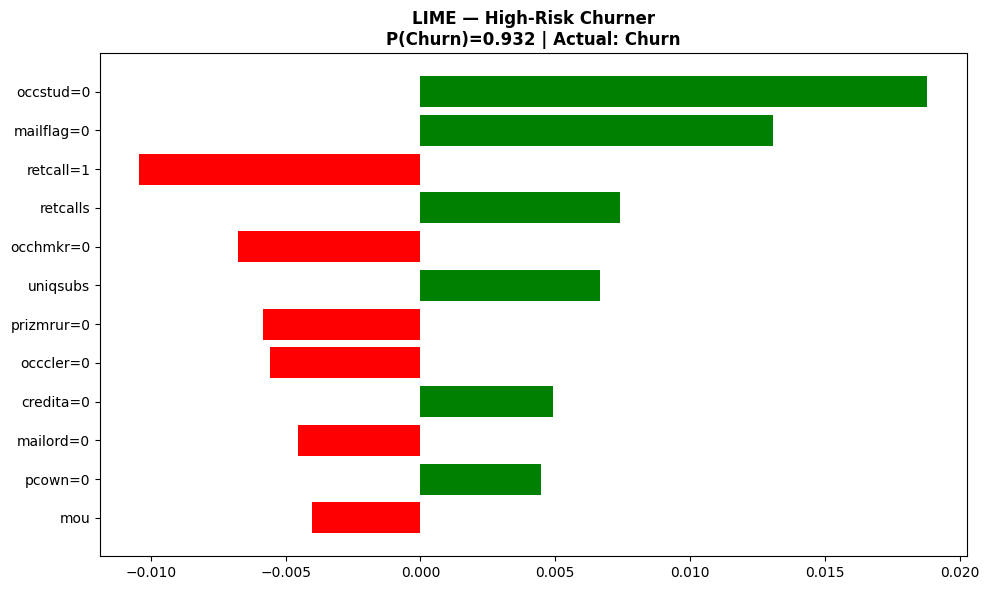

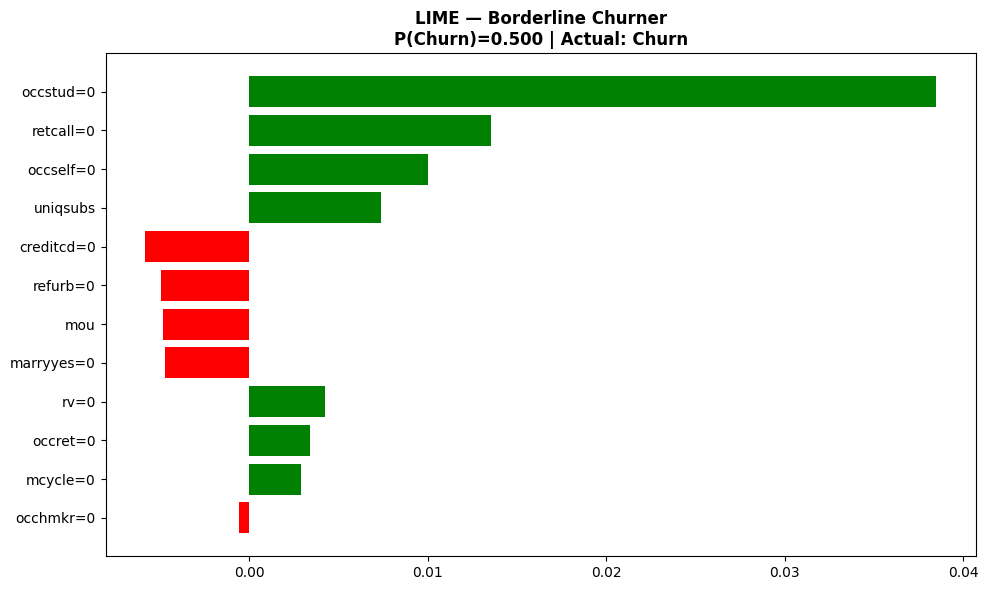

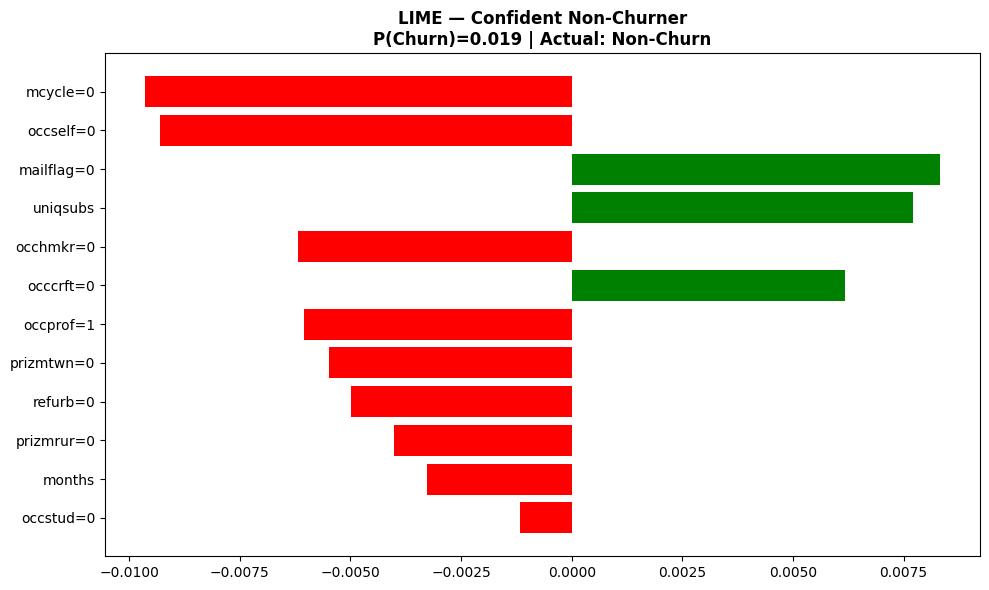

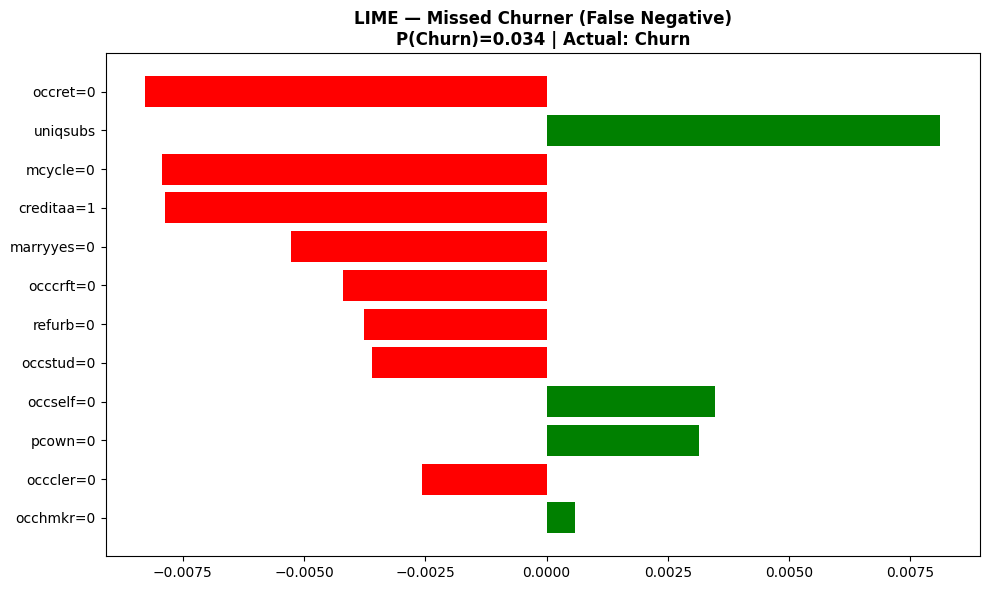

In [14]:
# ============================================================
# STEP 4: LOCAL LIME PLOTS — same 4 archetype customers as SHAP
# ============================================================
print("\n"+"="*60); print("STEP 4: LOCAL LIME EXPLANATIONS"); print("="*60)

probs = pd.Series(best_model.predict_proba(X_test_scaled)[:, 1], index=X_test_scaled.index)
for label, idx in examples.items():
    row = X_test_scaled.loc[idx].values
    exp = lime_explainer.explain_instance(row, predict_fn, num_features=12,
                                          labels=(1,), num_samples=NUM_SAMPLES)
    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(10, 6)
    plt.title(f'LIME — {label}\nP(Churn)={probs[idx]:.3f} | '
              f'Actual: {"Churn" if y_test[idx]==1 else "Non-Churn"}',
              fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


STEP 5: SHAP vs LIME (global teaser)


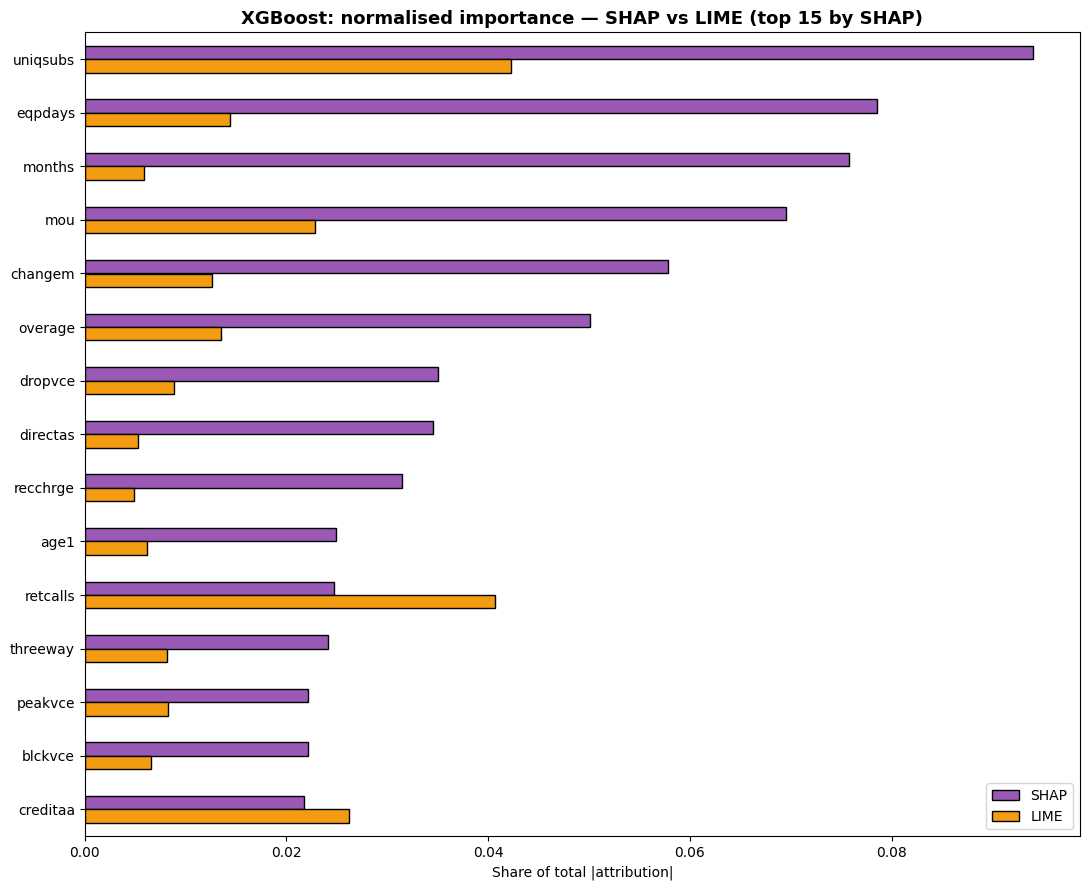


Top-10 feature overlap (SHAP vs LIME): 10%
Global rank correlation (Spearman): -0.329

SHAP top 5: ['uniqsubs', 'eqpdays', 'months', 'mou', 'changem']
LIME top 5: ['occhmkr', 'refer', 'uniqsubs', 'retcalls', 'occstud']


In [15]:
# ============================================================
# STEP 5: GLOBAL LIME IMPORTANCE + FIRST SHAP-vs-LIME COMPARISON
#   Previews Day 4's agreement metric (feature overlap + rank corr)
# ============================================================
print("\n"+"="*60); print("STEP 5: SHAP vs LIME (global teaser)"); print("="*60)

lime_imp = lime_eval_df.abs().mean().sort_values(ascending=False)
shap_imp = shap_eval_df.abs().mean().sort_values(ascending=False)

# Side-by-side top-15 bar (normalised so shapes are comparable)
comp = pd.DataFrame({'SHAP': shap_imp, 'LIME': lime_imp})
for c in comp.columns: comp[c] = comp[c] / comp[c].sum()
top_feats = comp['SHAP'].sort_values(ascending=False).head(15).index
comp.loc[top_feats].plot(kind='barh', figsize=(11, 9),
                         color=['#9b59b6', '#f39c12'], edgecolor='black')
plt.gca().invert_yaxis()
plt.title(f'{best_model_name}: normalised importance — SHAP vs LIME (top 15 by SHAP)',
          fontsize=13, fontweight='bold')
plt.xlabel('Share of total |attribution|'); plt.tight_layout(); plt.show()

# Quick agreement numbers on the eval set
shap_topk = set(shap_imp.head(TOPK).index)
lime_topk = set(lime_imp.head(TOPK).index)
overlap   = len(shap_topk & lime_topk) / TOPK
rho, _    = spearmanr(shap_imp[feature_names].values, lime_imp[feature_names].values)

print(f"\nTop-{TOPK} feature overlap (SHAP vs LIME): {overlap*100:.0f}%")
print(f"Global rank correlation (Spearman): {rho:.3f}")
print(f"\nSHAP top 5: {list(shap_imp.head(5).index)}")
print(f"LIME top 5: {list(lime_imp.head(5).index)}")

In [16]:
# ============================================================
# STEP 6: SAVE LIME OUTPUTS  (aligned to the SAME eval customers)
# ============================================================
print("\n"+"="*60); print("STEP 6: SAVING LIME OUTPUTS"); print("="*60)

lime_eval_df.to_csv(MODEL_PATH + 'lime_eval.csv')
print(f"Saved: lime_eval.csv {lime_eval_df.shape}")

lime_outputs = {
    'lime_eval': lime_eval_df,
    'eval_idx': list(eval_idx),
    'feature_names': feature_names,
    'best_model': best_model_name,
    'num_samples': NUM_SAMPLES,
    'topk_overlap': overlap,
    'global_spearman': rho,
    'categorical_features': cat_idx,   # record the fix for reproducibility
}
pickle.dump(lime_outputs, open(MODEL_PATH + 'lime_outputs.pkl', 'wb'))
print("Saved: lime_outputs.pkl")


STEP 6: SAVING LIME OUTPUTS
Saved: lime_eval.csv (500, 66)
Saved: lime_outputs.pkl


In [17]:
# ============================================================
# STEP 7: SUMMARY
# ============================================================
print("\n"+"="*60); print("DAY 3 SUMMARY"); print("="*60)
print(f"""
LIME generated for {len(eval_idx)} eval customers on {best_model_name}
  (num_samples={NUM_SAMPLES}, seed=42, discretize=False, {len(cat_idx)} categorical features)

First SHAP-vs-LIME read on the eval set:
  Top-{TOPK} feature overlap : {overlap*100:.0f}%
  Global rank correlation    : {rho:.3f}

Saved (same customers as SHAP -> ready for Day 4):
  lime_eval.csv, lime_outputs.pkl

NEXT: Day 4 — formal four-metric evaluation
  (fidelity, stability, sparsity, agreement) using
  xgb_shap_eval.csv  vs  lime_eval.csv
""")
print("DAY 3 COMPLETE.")


DAY 3 SUMMARY

LIME generated for 500 eval customers on XGBoost
  (num_samples=3000, seed=42, discretize=False, 32 categorical features)

First SHAP-vs-LIME read on the eval set:
  Top-10 feature overlap : 10%
  Global rank correlation    : -0.329

Saved (same customers as SHAP -> ready for Day 4):
  lime_eval.csv, lime_outputs.pkl

NEXT: Day 4 — formal four-metric evaluation
  (fidelity, stability, sparsity, agreement) using
  xgb_shap_eval.csv  vs  lime_eval.csv

DAY 3 COMPLETE.


In [18]:
# DIAGNOSTIC: is LIME weight tracking feature std rather than true importance?
from scipy.stats import spearmanr
stds = X_test_scaled[feature_names].std()
lime_imp2 = lime_eval_df.abs().mean()
shap_imp2 = shap_eval_df.abs().mean()
print("LIME |weight| vs feature std   Spearman:", round(spearmanr(lime_imp2.values, stds.values)[0], 3))
print("SHAP |value|  vs feature std   Spearman:", round(spearmanr(shap_imp2.values, stds.values)[0], 3))

LIME |weight| vs feature std   Spearman: 0.207
SHAP |value|  vs feature std   Spearman: -0.397


In [19]:
# DIAGNOSTIC: do LIME's local surrogates actually fit XGBoost? (R^2 of each local model)
scores = []
for idx in eval_idx[:100]:
    row = X_test_scaled.loc[idx].values
    exp = lime_explainer.explain_instance(row, predict_fn,
              num_features=len(feature_names), labels=(1,), num_samples=NUM_SAMPLES)
    scores.append(exp.score)
scores = np.array(scores)
print(f"LIME local surrogate R^2 over 100 instances:")
print(f"  mean={scores.mean():.3f}  median={np.median(scores):.3f}  "
      f"min={scores.min():.3f}  max={scores.max():.3f}")

LIME local surrogate R^2 over 100 instances:
  mean=0.125  median=0.114  min=0.080  max=0.857


In [20]:
# DIAGNOSTIC: find a kernel width that gives faithful local surrogates
import numpy as np
n_feat = len(feature_names)
default_kw = 0.75 * np.sqrt(n_feat)
print(f"Default kernel width: {default_kw:.2f}\n")

for mult in [1, 2, 4, 8]:
    kw = default_kw * mult
    expl = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_test_scaled.values, feature_names=feature_names,
        class_names=['Non-Churn','Churn'], categorical_features=cat_idx,
        mode='classification', discretize_continuous=False,
        random_state=42, kernel_width=kw)
    sc = []
    for idx in eval_idx[:60]:
        e = expl.explain_instance(X_test_scaled.loc[idx].values, predict_fn,
                num_features=n_feat, labels=(1,), num_samples=2000)
        sc.append(e.score)
    sc = np.array(sc)
    print(f"  mult={mult}  kw={kw:6.2f}  mean R^2={sc.mean():.3f}  median={np.median(sc):.3f}")

Default kernel width: 6.09

  mult=1  kw=  6.09  mean R^2=0.148  median=0.126
  mult=2  kw= 12.19  mean R^2=0.126  median=0.125
  mult=4  kw= 24.37  mean R^2=0.126  median=0.125
  mult=8  kw= 48.74  mean R^2=0.126  median=0.126


In [21]:
# CONFIRM: LIME fidelity on Logistic Regression (linear model -> should fit well)
lr_predict_fn = lambda x: lr_model.predict_proba(pd.DataFrame(x, columns=feature_names))
lr_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_scaled.values, feature_names=feature_names,
    class_names=['Non-Churn','Churn'], categorical_features=cat_idx,
    mode='classification', discretize_continuous=False, random_state=42)
sc = []
for idx in eval_idx[:60]:
    e = lr_lime.explain_instance(X_test_scaled.loc[idx].values, lr_predict_fn,
            num_features=len(feature_names), labels=(1,), num_samples=2000)
    sc.append(e.score)
sc = np.array(sc)
print(f"LIME R^2 on Logistic Regression: mean={sc.mean():.3f} median={np.median(sc):.3f}")

LIME R^2 on Logistic Regression: mean=0.994 median=0.994
